In [41]:
import networkx as nx
import math
import json
import geopandas as gpd
import geopandas as gpd
import random
import matplotlib.pyplot as plt

In [29]:
# 1. Initialize a Directed Graph
G = nx.DiGraph()


In [30]:
# 1. Load the live data from the previous notebook
with open('data/live_weather_config.json', 'r') as f:
    live_weather = json.load(f)

# 2. Extract the variables
live_wind_speed = live_weather['wind_speed']
raw_wind_dir = live_weather['wind_direction']

sim_wind_speed = max(50, live_wind_speed)

# 3. The NWS Wind to Push-Vector Dictionary
push_vector_map = {
    'W': 0,    'WNW': 337.5, 'NW': 315,  'NNW': 292.5, # Wind from West pushes East (0°)
    'S': 90,   'SSW': 67.5,  'SW': 45,   'WSW': 22.5,  # Wind from South pushes North (90°)
    'E': 180,  'ESE': 157.5, 'SE': 135,  'SSE': 112.5, # Wind from East pushes West (180°)
    'N': 270,  'NNE': 247.5, 'NE': 225,  'ENE': 202.5  # Wind from North pushes South (270°)
}

# 4. Convert the text to the mathematical Push Vector
wind_vector = push_vector_map.get(raw_wind_dir, 0) # Defaults to 0 if not found
c_factor = 0.08

In [31]:
moore_offsets = [
    (0, 1, 0, 1.0),      # East (0°)
    (1, 0, 90, 1.0),     # North (90°)
    (0, -1, 180, 1.0),   # West (180°)
    (-1, 0, 270, 1.0),   # South (270°)
    (1, 1, 45, 1.414),    # NE (45°)
    (1, -1, 135, 1.414),  # NW (135°)
    (-1, -1, 225, 1.414), # SW (225°)
    (-1, 1, 315, 1.414)   # SE (315°)
]

In [32]:
# 3. Create a function to calculate the edge weight
def calculate_edge_weight(base_risk, edge_angle, wind_vector, wind_speed):
    # Get the absolute difference in angles
    angle_diff = abs(wind_vector - edge_angle)
    
    # Convert to radians for Python's math.cos()
    angle_diff_rad = math.radians(angle_diff)
    
    # Apply the Exponential CA Equation
    directional_multiplier = math.exp(c_factor * wind_speed * math.cos(angle_diff_rad))
    
    # Calculate final spread probability (cap it at 1.0 or 100%)
    final_spread_prob = min(1.0, base_risk * directional_multiplier)
    
    return final_spread_prob

In [33]:
# Load the fixed backbone
grid_gdf = gpd.read_file("data/spatial_backbone.geojson")

# Reconstruct the grid_nodes list from the saved IDs
# We split the string "5_10" back into the tuple (5, 10)
grid_nodes = [tuple(map(int, x.split('_'))) for x in grid_gdf['node_id']]

In [34]:
def build_networkx_grid(grid_nodes, default_base_risk=0.3):
    for r, c in grid_nodes:
        for dr, dc, edge_angle, dist_adj in moore_offsets:
            neighbor = (r + dr, c + dc)
            
            # Only add edge if the neighbor exists in your Seattle fishnet
            if neighbor in grid_nodes:
                # Calculate anisotropic weight
                weight = calculate_edge_weight(
                    base_risk=default_base_risk, 
                    edge_angle=edge_angle, 
                    wind_vector=wind_vector, 
                    wind_speed=sim_wind_speed
                )
                
                # Apply distance decay for diagonals
                final_weight = weight / dist_adj
                
                G.add_edge((r, c), neighbor, weight=final_weight)
    return G

G = build_networkx_grid(grid_nodes)
print(f"Graph built with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Graph built with 2790 nodes and 21682 edges.


In [35]:
# Set all nodes to unburned initially
nx.set_node_attributes(G, 0, 'status')

# # Pick an ignition point (e.g., a node near a high-risk infrastructure point)
# ignition_node = list(G.nodes())[500] # Just an example index
# G.nodes[ignition_node]['status'] = 1

# 2. Pick a center point (your previous 20, 30 is fine)
center_c, center_r = (20, 30)

# 3. Ignite a 3x3 cluster to ensure a sustained start
for dc in [-1, 0, 1]:
    for dr in [-1, 0, 1]:
        target_node = (center_c + dc, center_r + dr)
        if target_node in G:
            G.nodes[target_node]['status'] = 1

print(f"Sustained ignition cluster started at {center_c, center_r}")

Sustained ignition cluster started at (20, 30)


In [36]:
def run_spread_step(G):
    new_ignitions = []
    burning_nodes = [n for n, attr in G.nodes(data=True) if attr['status'] == 1]
    
    for node in burning_nodes:
        # Check all outgoing edges (potential spread directions)
        for _, neighbor, data in G.out_edges(node, data=True):
            if G.nodes[neighbor]['status'] == 0:
                # Roll the dice against the edge weight
                if random.random() < data['weight']:
                    new_ignitions.append(neighbor)
        
        # After attempting to spread, the current node burns out
        G.nodes[node]['status'] = 2
        
    # Update the status of newly ignited nodes
    for node in new_ignitions:
        G.nodes[node]['status'] = 1
    
    return len(new_ignitions)

In [37]:
# 1. Initialize all nodes as 'Unburned' (State 0)
nx.set_node_attributes(G, 0, 'status')

# 2. Pick an Ignition Point
# Let's pick a node in the center of your grid for the first test run
# Or use grid_nodes[len(grid_nodes)//2]
ignition_node = (20, 30) # Use an actual (c, r) tuple from your grid_nodes
G.nodes[ignition_node]['status'] = 1 

print(f"Ignition started at node: {ignition_node}")

Ignition started at node: (20, 30)


In [38]:
def simulate_spread(G, iterations=20):
    # Store results: {step_number: [list_of_burning_nodes]}
    spread_history = {}
    
    for t in range(iterations):
        # Identify nodes currently on fire
        active_front = [n for n, attr in G.nodes(data=True) if attr['status'] == 1]
        spread_history[t] = active_front
        
        if not active_front:
            print(f"Fire extinguished at step {t}")
            break
            
        new_ignitions = []
        
        for node in active_front:
            # Check neighbors via outgoing edges
            for _, neighbor, data in G.out_edges(node, data=True):
                if G.nodes[neighbor]['status'] == 0:
                    # The Stochastic Roll: random number vs edge weight
                    if random.random() < data['weight']:
                        new_ignitions.append(neighbor)
            
            # This cell has finished burning its fuel
            G.nodes[node]['status'] = 2
            
        # Update the new front
        for n in set(new_ignitions):
            G.nodes[n]['status'] = 1
            
    return spread_history

# Run it!
history = simulate_spread(G, iterations=60)

# Print the progress to confirm it's working
for step, active in history.items():
    if step % 10 == 0:
        print(f"Step {step}: {len(active)} nodes currently burning.")

Fire extinguished at step 33
Step 0: 1 nodes currently burning.
Step 10: 28 nodes currently burning.
Step 20: 57 nodes currently burning.
Step 30: 30 nodes currently burning.


Simulation ended: No active fire front remaining.


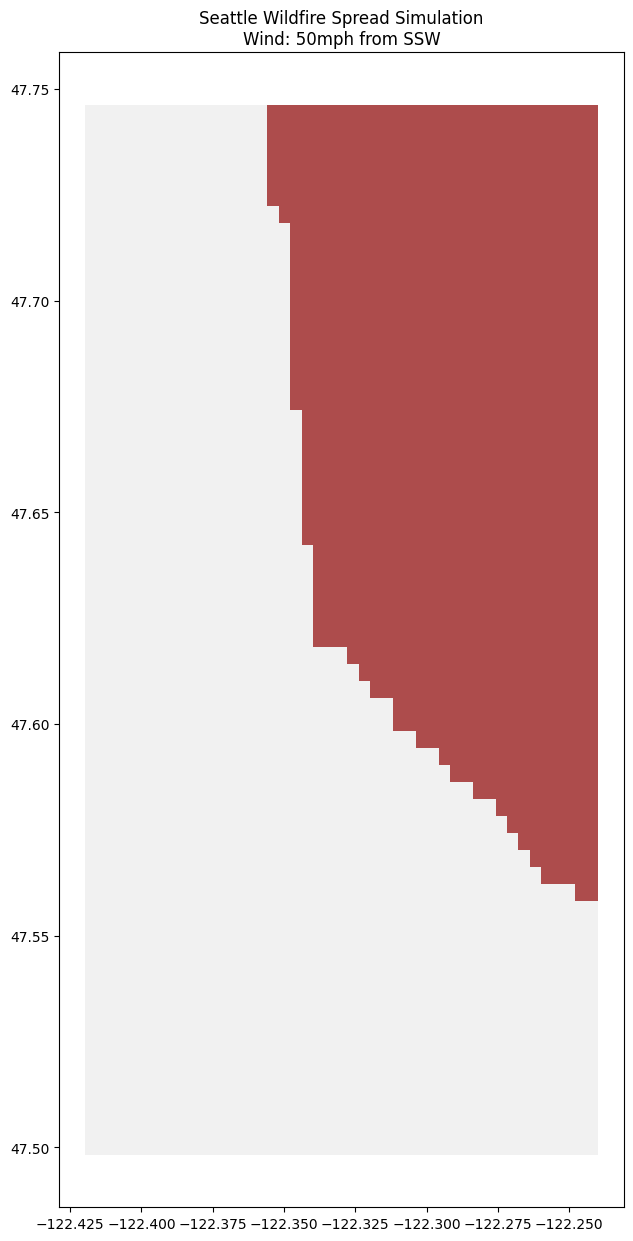

In [42]:
fig, ax = plt.subplots(figsize=(10, 15))

# 1. Plot the unburned areas (Grey)
grid_gdf[grid_gdf['final_status'] == 0].plot(ax=ax, color='lightgrey', alpha=0.3, edgecolor='white', linewidth=0.1)

# 2. Plot the burned-out areas (Dark Red)
burned = grid_gdf[grid_gdf['final_status'] == 2]
if not burned.empty:
    burned.plot(ax=ax, color='darkred', alpha=0.7, label='Burned Area')

# 3. Plot the final active front (Orange) - This was the empty one!
active = grid_gdf[grid_gdf['final_status'] == 1]
if not active.empty:
    active.plot(ax=ax, color='orange', label='Active Front')
else:
    print("Simulation ended: No active fire front remaining.")

ax.set_title(f"Seattle Wildfire Spread Simulation\nWind: {sim_wind_speed}mph from {raw_wind_dir}")
plt.show()

In [43]:
def run_monte_carlo(G, ignition_node, iterations=30, n_sims=50):
    # Dictionary to track how many times each node burned
    burn_counts = {node: 0 for node in G.nodes()}
    
    for i in range(n_sims):
        # Reset and run spread
        nx.set_node_attributes(G, 0, 'status')
        G.nodes[ignition_node]['status'] = 1 # You can also use the 3x3 cluster here
        
        # We only need the final state, so we run the simulation fully
        simulate_spread(G, iterations=iterations)
        
        # Increment counts for nodes that reached Status 2
        for node, attr in G.nodes(data=True):
            if attr['status'] == 2:
                burn_counts[node] += 1
                
    # Calculate probability (0.0 to 1.0)
    burn_probs = {node: count / n_sims for node, count in burn_counts.items()}
    return burn_probs

# Run the risk assessment
risk_map = run_monte_carlo(G, (20, 30), n_sims=20)

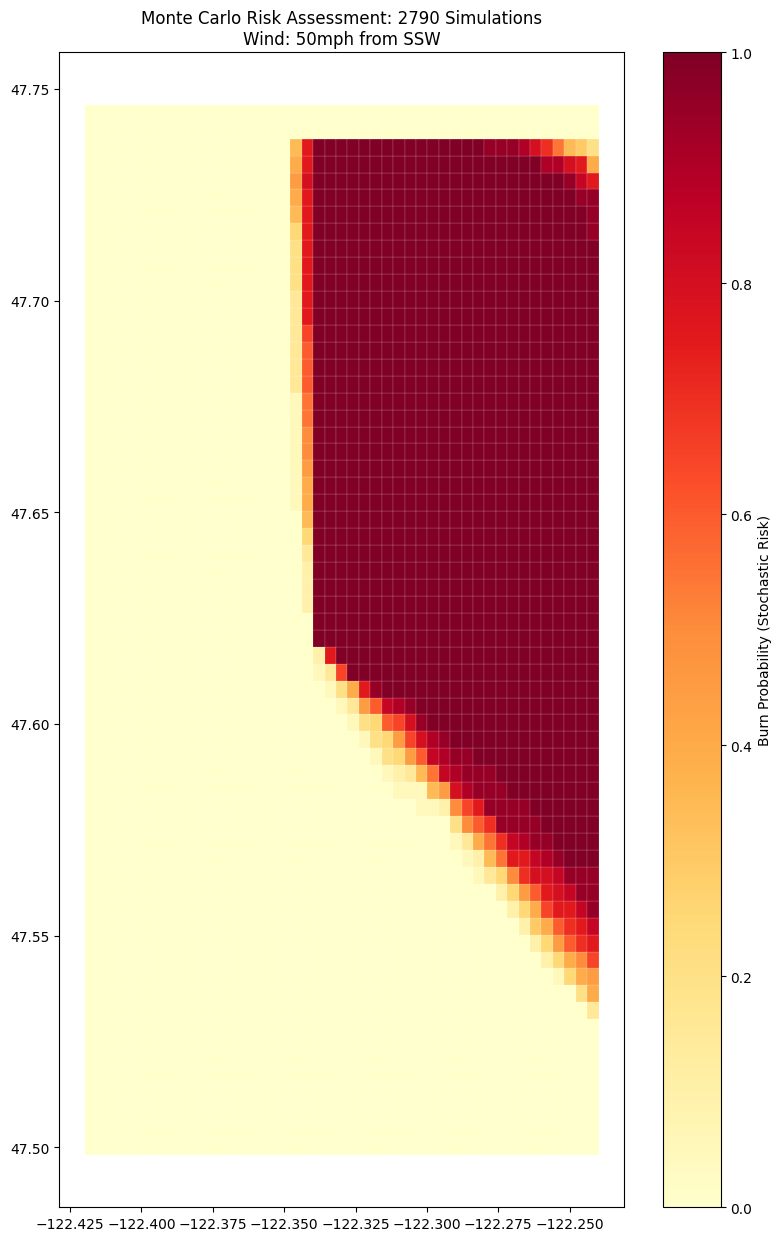

In [45]:
# 1. Map the probabilities back to the GeoDataFrame
# We reconstruct the 'node_id' string to match your GDF
grid_gdf['burn_probability'] = grid_gdf['node_id'].apply(
    lambda x: risk_map.get(tuple(map(int, x.split('_'))), 0)
)

# 2. Plot the Heatmap
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 15))

# Plot the grid colored by probability
grid_gdf.plot(
    column='burn_probability', 
    ax=ax, 
    cmap='YlOrRd', # Yellow-Orange-Red colormap
    legend=True, 
    legend_kwds={'label': "Burn Probability (Stochastic Risk)"},
    edgecolor='white', 
    linewidth=0.1
)

ax.set_title(f"Monte Carlo Risk Assessment: {len(risk_map)} Simulations\nWind: {sim_wind_speed}mph from {raw_wind_dir}")
plt.show()

In [46]:
# 1. Save the GeoDataFrame with the new 'burn_probability' column
# This allows you to load the spatial risk map instantly in the next notebook
grid_gdf.to_file("data/seattle_burn_risk_profile.geojson", driver='GeoJSON')

# 2. Export the final weighted Graph
# This preserves the directed edges and anisotropic weights
import pickle
with open('data/final_fire_graph.pkl', 'wb') as f:
    pickle.dump(G, f)